In [2]:
import pandas as pd
import glob
import os

def combine_and_aggregate(input_folder="data", output_file="combined_data.csv"):
    """
    Reads all CSV files in `input_folder`, concatenates them, and computes
    the mean Vehicle Count and mean Density grouped by (Time, Detector ID, Scenario).
    Saves the result to `output_file`.
    """
    # 1. Gather all relevant CSV files
    csv_files = glob.glob(os.path.join(input_folder, "data_*.csv"))
    
    # 2. Concatenate all files into one DataFrame
    all_dfs = []
    for f in csv_files:
        # Read each CSV; if semicolon-delimited, add sep=';' as needed
        df = pd.read_csv(f)
        all_dfs.append(df)
    
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    # 3. Group by (Time (s), Detector ID, Scenario) and compute mean over seeds
    grouped = (
        combined_df
        .groupby(["Time (s)", "Detector ID", "Scenario"], as_index=False)
        .agg({
            "Vehicle Count": "mean",
            "Density (veh/km)": "mean"
        })
    )
    
    # Optionally rename columns to something like 'Mean Vehicle Count' or 'Average Density'
    grouped.rename(columns={
        "Vehicle Count": "Mean Vehicle Count",
        "Density (veh/km)": "Mean Density (veh/km)"
    }, inplace=True)
    
    # 4. Save the final DataFrame
    grouped.to_csv(output_file, index=False)
    print(f"Aggregated data saved to {output_file}")

if __name__ == "__main__":
    combine_and_aggregate(
        input_folder="data", 
        output_file="data/combined_data.csv"
    )


Aggregated data saved to data/combined_data.csv


In [3]:
import pandas as pd
import xml.etree.ElementTree as ET

DETECTORS_FILE = "lanedetectors.add.xml" 
DATA_FILE = "data/combined_data.csv"  
BIN_SIZE = 300  # 5-minute intervals
T_START = 0  # Arbitrary start time for binning

def main():
    global combined_results
    # Load detectors from XML file
    detector_ids = load_detectors_from_xml(DETECTORS_FILE)
    cross_section_map = parse_cross_sections(detector_ids)

    # Aggregate data with binning
    combined_results = combined_output(DATA_FILE, cross_section_map, bin_size=BIN_SIZE, t_start=T_START)

    print(combined_results.head())

    # Save to CSV
    combined_results.to_csv("data/combined_datav2.csv", index=False)
    print("Data saved to data/combined_datav2.csv")

    return combined_results


def parse_cross_sections(detector_ids):
    """Group detectors into edges by excluding the middle part of the detector ID."""
    cross_section_map = {}
    for detector_id in detector_ids:
        # Extract edge and position by removing the middle part (e.g., E1_0_1000m -> E1_1000m)
        parts = detector_id.split("_")
        if len(parts) == 3:
            edge = f"{parts[0]}_{parts[2]}"  # Combine the first and last parts
        else:
            edge = detector_id  # Fallback for unexpected formats
        cross_section_map[detector_id] = edge
    return cross_section_map

def load_detectors_from_xml(detectors_file):
    """Load detector IDs from the XML file."""
    tree = ET.parse(detectors_file)
    root = tree.getroot()
    detector_ids = [detector.get("id") for detector in root.findall("laneAreaDetector")]
    return detector_ids

def combined_output(csv_file, cs_map, bin_size=300, t_start=0):
    """Aggregates data into time bins and merges detector IDs."""

    # Load CSV file
    df = pd.read_csv(csv_file)

    # Rename columns for consistency
    df.rename(columns={
        "Time (s)": "time",
        "Detector ID": "detectorID",
        "Mean Vehicle Count": "count",
        "Mean Density (veh/km)": "density",
        "Scenario": "scenario"
    }, inplace=True)

    # Map Detector IDs to their simplified names
    df["detectorID"] = df["detectorID"].map(cs_map)

    # Ensure only times from `t_start` onwards are considered
    df = df[df["time"] >= t_start]

    # Create `time_bin` based on `t_start` and `bin_size`
    df["time_bin"] = ((df["time"] - t_start) // bin_size) * bin_size + t_start

    # Ensure we don't mix scenarios when aggregating
    grouped = df.groupby(["time_bin", "detectorID", "scenario"], as_index=False)
    
    aggregated_df = grouped.agg(
        count=("count", "sum"),  # Sum of vehicle counts
        density=("density", "mean"),  # Average density
    )

    return aggregated_df

if __name__ == "__main__":
    main()

   time_bin       detectorID scenario   count    density
0   53100.0     104359041_0m   attack  1843.8  15.416388
1   53100.0     104359041_0m     base  1843.8  15.416388
2   53100.0  104359041_1000m   attack  1561.0  13.051839
3   53100.0  104359041_1000m     base  1561.0  13.051839
4   53100.0   104359041_100m   attack  1798.0  15.033445
Data saved to data/combined_datav2.csv


In [4]:
def calculate_ratios(data):
    """Calculate Speed Performance Ratio (SPR) and Flow Ratio (FR)."""

    # Separate attack and base scenarios
    attack_data = data[data["scenario"] == "attack"]
    base_data = data[data["scenario"] == "base"]

    # Merge attack and base data for comparison (EXCLUDING scenario from the merge key)
    merged_data = pd.merge(
        attack_data,
        base_data,
        on=["time_bin", "detectorID"],  # Corrected merge condition
        suffixes=("_attack", "_base")
    )

    # Debugging: Check merged data
    print("Merged Data Preview:")
    print(merged_data.head())

    # Select and format output columns
    output_data = merged_data[[
        "time_bin",
        "detectorID",
        "density_attack",
        "density_base"
    ]].round(2)  # Round all numeric columns to 2 decimal places

    return output_data

# Load combined data from CSV
comb_results = pd.read_csv("data/combined_datav2.csv")

# Calculate ratios and save to CSV
ratios = calculate_ratios(comb_results)
ratios.to_csv("data/combined_datav3.csv", index=False)
print("Ratios saved to data/combined_datav3.csv")


Merged Data Preview:
   time_bin       detectorID scenario_attack  count_attack  density_attack  \
0   53100.0     104359041_0m          attack        1843.8       15.416388   
1   53100.0  104359041_1000m          attack        1561.0       13.051839   
2   53100.0   104359041_100m          attack        1798.0       15.033445   
3   53100.0  104359041_1100m          attack        1541.4       12.887960   
4   53100.0  104359041_1200m          attack        1518.4       12.695652   

  scenario_base  count_base  density_base  
0          base      1843.8     15.416388  
1          base      1561.0     13.051839  
2          base      1798.0     15.033445  
3          base      1541.4     12.887960  
4          base      1518.4     12.695652  
Ratios saved to data/combined_datav3.csv


In [5]:
ratios = pd.read_csv("data/combined_datav3.csv")

# convert veh/km/lane to vveh/mile/lane for density
ratios['density_attack'] = ratios['density_attack'] * 1.60934
ratios['density_base'] = ratios['density_base'] * 1.60934

# Define LOS classification function for urban freeway density
def classify_LOS(density):
    if density <= 11:
        return "A"
    elif 11 < density <= 18:
        return "B"
    elif 18 < density <= 26:
        return "C"
    elif 26 < density <= 35:
        return "D"
    elif 35 < density <= 45:
        return "E"
    else:
        return "F"
    
# Apply LOS classification to both scenarios
ratios["LOS_attack"] = ratios["density_attack"].apply(classify_LOS)
ratios["LOS_base"] = ratios["density_base"].apply(classify_LOS)

# Define function to assign distance based on detectorID
def assign_distance(detector_id):
    """Assigns distance based on the detectorID."""
    if detector_id.startswith("104359041_"):
        base_distance = 0
    elif detector_id.startswith("E1_"):
        base_distance = 2000
    elif detector_id.startswith("E2_"):
        base_distance = 4000
    else:
        return None  # If the format doesn't match expected values

    # Extract the numeric part of the detectorID (distance suffix)
    suffix_distance = int(detector_id.split("_")[1][:-1])  # Extract number before 'm'
    
    return base_distance + suffix_distance

ratios["distance"] = ratios["detectorID"].apply(assign_distance)

# Sort the DataFrame
ratios_sorted = ratios.sort_values(by=["time_bin", "distance"], ascending=[True, True])

print(ratios_sorted.head())

# Drop helper columns used for sorting
# ratios_sorted = ratios_sorted.drop(columns=["road", "distance"])



# Save to CSV
ratios_sorted.to_csv("data/combined_datav4.csv", index=False)
print("Ratios saved to data/combined_datav4.csv")



    time_bin      detectorID  density_attack  density_base LOS_attack  \
0    53100.0    104359041_0m       24.816023     24.816023          C   
2    53100.0  104359041_100m       24.188380     24.188380          C   
13   53100.0  104359041_200m       23.560738     23.560738          C   
24   53100.0  104359041_300m       23.254963     23.254963          C   
34   53100.0  104359041_400m       22.852628     22.852628          C   

   LOS_base  distance  
0         C         0  
2         C       100  
13        C       200  
24        C       300  
34        C       400  
Ratios saved to data/combined_datav4.csv


/tmp/ipykernel_4178985/97507800.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot_df.applymap(lambda x: LOS_map[x] if pd.notnull(x) else np.nan)
/tmp/ipykernel_4178985/97507800.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])  # Leave room on the right for cbar


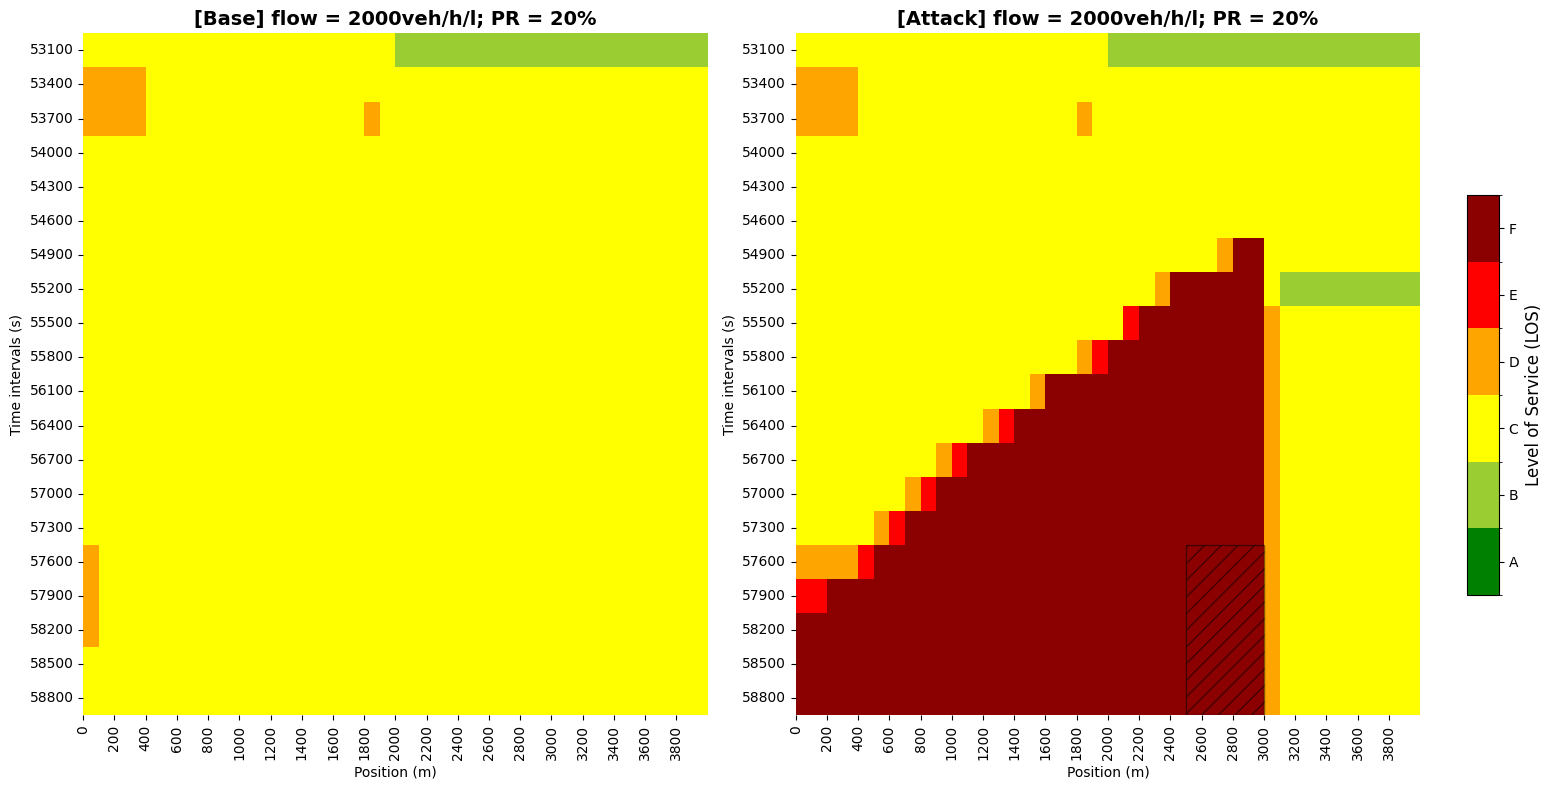

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as patches

# ------------------------------------------------------------------------
# 1. Read Data
# ------------------------------------------------------------------------
file_path = "data/combined_datav4.csv"
df = pd.read_csv(file_path)

# Convert time_bin and distance to int if needed
df["time_bin"] = df["time_bin"].astype(int)
df["distance"] = df["distance"].astype(int)

# ------------------------------------------------------------------------
# 2. Split Attack vs. Base and rename LOS columns for pivoting
# ------------------------------------------------------------------------
df_base = df[["time_bin", "distance", "LOS_base"]].copy()
df_attack = df[["time_bin", "distance", "LOS_attack"]].copy()

df_base.rename(columns={"LOS_base": "LOS"}, inplace=True)
df_attack.rename(columns={"LOS_attack": "LOS"}, inplace=True)

# ------------------------------------------------------------------------
# 3. Filter by distance/time range (adjust if needed)
# ------------------------------------------------------------------------
distance_start = 0
distance_end   = 3900
time_start     = 53100
time_end       = 58800

df_base = df_base[
    (df_base["distance"] >= distance_start) &
    (df_base["distance"] <= distance_end) &
    (df_base["time_bin"] >= time_start) &
    (df_base["time_bin"] <= time_end)
]

df_attack = df_attack[
    (df_attack["distance"] >= distance_start) &
    (df_attack["distance"] <= distance_end) &
    (df_attack["time_bin"] >= time_start) &
    (df_attack["time_bin"] <= time_end)
]

# ------------------------------------------------------------------------
# 4. Pivot into matrices: index=time_bin, columns=distance, values=LOS
# ------------------------------------------------------------------------
pivot_base   = df_base.pivot(index="time_bin", columns="distance", values="LOS")
pivot_attack = df_attack.pivot(index="time_bin", columns="distance", values="LOS")

# ------------------------------------------------------------------------
# 5. Map LOS (A–F) to numeric
# ------------------------------------------------------------------------
LOS_map = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6}

def map_LOS_to_numeric(pivot_df):
    return pivot_df.applymap(lambda x: LOS_map[x] if pd.notnull(x) else np.nan)

base_numeric   = map_LOS_to_numeric(pivot_base)
attack_numeric = map_LOS_to_numeric(pivot_attack)

# ------------------------------------------------------------------------
# 6. Create a discrete colormap for LOS
# ------------------------------------------------------------------------
los_colors = ["green", "yellowgreen", "yellow", "orange", "red", "darkred"]
cmap = ListedColormap(los_colors)
bounds = [0.5,1.5,2.5,3.5,4.5,5.5,6.5]
norm = BoundaryNorm(bounds, cmap.N)

# ------------------------------------------------------------------------
# 7. Plot the two heatmaps: BASE on the LEFT, ATTACK on the RIGHT
# ------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# --- BASE Scenario (left) ---
sns.heatmap(
    base_numeric,
    ax=axes[0],
    cmap=cmap,
    norm=norm,
    cbar=False,
    square=False
)
axes[0].set_title("[Base] flow = 2000veh/h/l; PR = 20%", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Position (m)")
axes[0].set_ylabel("Time intervals (s)")  # show y-label on base scenario

# Example: label x‐ticks more sparsely
axes[0].set_xticks(np.arange(0, len(pivot_base.columns), 2))
axes[0].set_xticklabels(pivot_base.columns[::2], rotation=90)

# --- ATTACK Scenario (right) ---
sns.heatmap(
    attack_numeric,
    ax=axes[1],
    cmap=cmap,
    norm=norm,
    cbar=False,
    square=False
)
axes[1].set_title("[Attack] flow = 2000veh/h/l; PR = 20%", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Position (m)")
axes[1].set_ylabel("Time intervals (s)")  # explicitly add y-label if desired

# Example: label x‐ticks more sparsely
axes[1].set_xticks(np.arange(0, len(pivot_base.columns), 2))
axes[1].set_xticklabels(pivot_base.columns[::2], rotation=90)

# axes is your array of subplots, e.g. axes[0] for base, axes[1] for attack

# col_index_3000 = pivot_attack.columns.get_loc(3000)
# col_index_4000 = pivot_attack.columns.get_loc(4000)
# row_index_2400 = pivot_attack.index.get_loc(2400)
# row_index_4200 = pivot_attack.index.get_loc(4200)
# row_index_6000 = pivot_attack.index.get_loc(6000)

# for ax in axes:
#     # Vertical line at distance=3000
#     ax.axvline(x=col_index_3000, color="k", linestyle="--", lw=1)
#     # Vertical line at distance=4000
#     ax.axvline(x=col_index_4000, color="k", linestyle="--", lw=1)
#     # Horizontal line at time=2400
#     ax.axhline(y=row_index_2400, color="k", linestyle="--", lw=1)
#     ax.axhline(y=row_index_4200, color="k", linestyle="--", lw=1)
#     ax.axhline(y=row_index_6000, color="k", linestyle="--", lw=1)

# axes[1].text(
#     0.67, 0.94, "Spoofed VSL:\n 50 mph",
#     transform=axes[1].transAxes, 
#     ha="right", va="bottom",
#     color="black", fontsize=10
# )

# axes[1].text(
#     0.67, 0.69, "Spoofed VSL:\n 40 mph",
#     transform=axes[1].transAxes, 
#     ha="right", va="bottom",
#     color="black", fontsize=10
# )

# axes[1].text(
#     0.67, 0.44, "Spoofed VSL:\n 30 mph",
#     transform=axes[1].transAxes, 
#     ha="right", va="bottom",
#     color="black", fontsize=10
# )

# axes[1].text(
#     0.45, 0.3, "Emergency brake\nactivated",
#     transform=axes[1].transAxes, 
#     ha="right", va="bottom",
#     color="black", fontsize=10
# )

# # arrow
# ax.arrow(
#     0.46, 0.32,           # tail (axes fraction)
#     0.50 - 0.46, 0.255 - 0.32,  # head offset
#     transform=ax.transAxes,
#     color="black",
#     linewidth=1,
#     head_width=0.02,
#     head_length=0.02,
#     length_includes_head=True,
#     zorder=10
# )

# axes[1].text(
#     0.45, 0.08, "Phantom\nlane closure",
#     transform=ax.transAxes,
#     ha="right", va="bottom",
#     color="black", fontsize=10
# )

# # arrow
# ax.arrow(
#     0.46, 0.105,           # tail (axes fraction)
#     0.62 - 0.46, 0.2 - 0.105,  # head offset
#     transform=ax.transAxes,
#     color="black",
#     linewidth=1,
#     head_width=0.02,
#     head_length=0.02,
#     length_includes_head=True,
#     zorder=10
# )

# Define the rectangle in fraction coordinates
xFrac      = 0.625
yFrac      = 0.0
widthFrac  = 0.125
heightFrac = 0.25


# For the right subplot (axes[1])
rect_right = patches.Rectangle(
    (xFrac, yFrac),
    widthFrac,
    heightFrac,
    facecolor="none",
    edgecolor="black",
    hatch="//",
    linewidth=1,
    zorder=10,
    alpha = 0.5
)
rect_right.set_transform(axes[1].transAxes)  # interpret coords as fraction of Axes[1]
axes[1].add_patch(rect_right)

# ------------------------------------------------------------------------
# 8. Add a colorbar on the far right
# ------------------------------------------------------------------------
# By default, fig.colorbar() tries to place the colorbar in the middle.
# We can give it its own Axes to ensure it's on the far right:
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=cbar_ax,
    orientation='vertical'
)

# Label ticks A-F
cbar.set_ticks([1,2,3,4,5,6])
cbar.set_ticklabels(["A", "B", "C", "D", "E", "F"])
cbar.set_label("Level of Service (LOS)", fontsize=12)

plt.tight_layout(rect=[0, 0, 0.90, 1])  # Leave room on the right for cbar
plt.savefig("LOSHigh-20.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\nalin\AppData\Local\Temp\ipykernel_39896\1315326665.py:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot_df.applymap(lambda x: LOS_map[x] if pd.notnull(x) else np.nan)


[   0  300  600  900 1200 1500 1800 2100 2400 2700 3000 3300]


C:\Users\nalin\AppData\Local\Temp\ipykernel_39896\1315326665.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


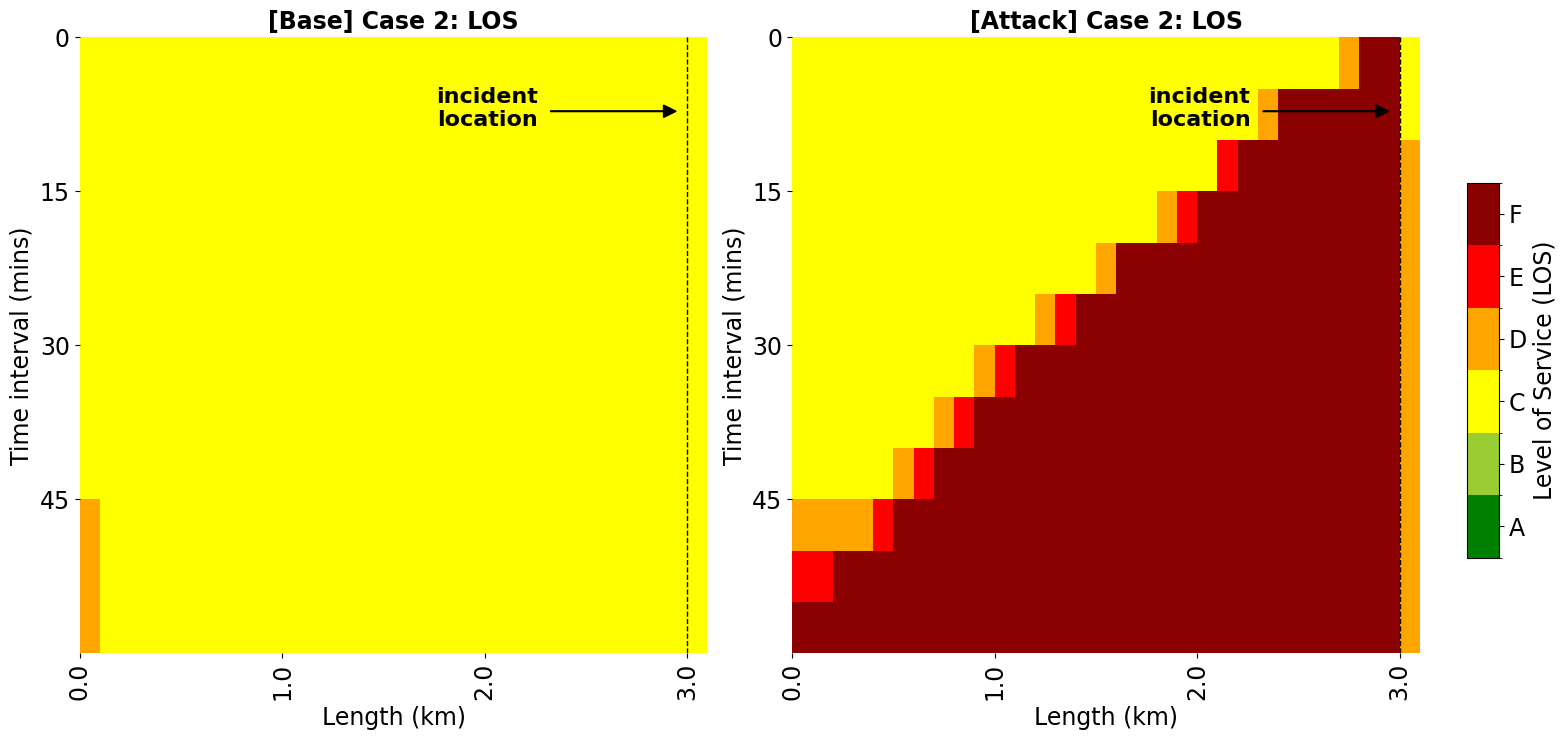

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as patches

# ------------------------------------------------------------------------
# 1. Read Data
# ------------------------------------------------------------------------
file_path = "data/combined_datav4.csv"
df = pd.read_csv(file_path)

df["time_bin"] = df["time_bin"].astype(int)
df["distance"] = df["distance"].astype(int)

# ------------------------------------------------------------------------
# 2. Split Attack vs. Base
# ------------------------------------------------------------------------
df_base = df[["time_bin", "distance", "LOS_base"]].copy()
df_attack = df[["time_bin", "distance", "LOS_attack"]].copy()

df_base.rename(columns={"LOS_base": "LOS"}, inplace=True)
df_attack.rename(columns={"LOS_attack": "LOS"}, inplace=True)

# ------------------------------------------------------------------------
# 3. Filter by distance/time range
# ------------------------------------------------------------------------
distance_start = 0
distance_end   = 3000
time_start     = 54900
time_end       = 58200

df_base = df_base[
    (df_base["distance"] >= distance_start) &
    (df_base["distance"] <= distance_end) &
    (df_base["time_bin"] >= time_start) &
    (df_base["time_bin"] <= time_end)
]

df_attack = df_attack[
    (df_attack["distance"] >= distance_start) &
    (df_attack["distance"] <= distance_end) &
    (df_attack["time_bin"] >= time_start) &
    (df_attack["time_bin"] <= time_end)
]

# ------------------------------------------------------------------------
# 4. Pivot into matrices
# ------------------------------------------------------------------------
pivot_base   = df_base.pivot(index="time_bin", columns="distance", values="LOS")
pivot_attack = df_attack.pivot(index="time_bin", columns="distance", values="LOS")

# ------------------------------------------------------------------------
# 5. Map LOS A–F → 1–6
# ------------------------------------------------------------------------
LOS_map = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6}
def map_LOS_to_numeric(pivot_df):
    return pivot_df.applymap(lambda x: LOS_map[x] if pd.notnull(x) else np.nan)

base_numeric   = map_LOS_to_numeric(pivot_base)
attack_numeric = map_LOS_to_numeric(pivot_attack)

# ------------------------------------------------------------------------
# 6. Discrete colormap for LOS
# ------------------------------------------------------------------------
los_colors = ["green", "yellowgreen", "yellow", "orange", "red", "darkred"]
cmap = ListedColormap(los_colors)
bounds = [0.5,1.5,2.5,3.5,4.5,5.5,6.5]
norm = BoundaryNorm(bounds, cmap.N)

# ------------------------------------------------------------------------
# 7. Plot base vs attack
# ------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=False)

# --- Tick positions and labels ---
col_positions = np.arange(0, len(pivot_base.columns), 10)
x_labels_km = [f"{pivot_base.columns[i]/1000:.1f}" for i in col_positions]

time_values = pivot_base.index.values - 54900
print(time_values)
# n_ticks = 4
# row_positions = np.linspace(0, len(time_values)-1, n_ticks, dtype=int)
# y_labels_min = [f"{time_values[i]/60:.0f}" for i in row_positions]

y_tick_positions = [i for i, t in enumerate(time_values) if (t % 900) == 0]  # 900 seconds = 15 mins
y_tick_labels = [f"{int(time_values[i] / 60)}" for i in y_tick_positions]  # convert to minutes

# --- BASE Heatmap (left) ---
sns.heatmap(base_numeric, ax=axes[0], cmap=cmap, norm=norm, cbar=False, square=False, yticklabels=False)
axes[0].set_title("[Base] Case 2: LOS", fontsize=17, fontweight="bold")
axes[0].set_xlabel("Length (km)", fontsize=17)
axes[0].set_ylabel("Time interval (mins)", fontsize=17)
axes[0].set_xticks(col_positions)
axes[0].set_xticklabels(x_labels_km, rotation=90, fontsize=17)
axes[0].set_yticks(y_tick_positions)
axes[0].set_yticklabels(y_tick_labels, fontsize=17)

# --- ATTACK Heatmap (right) ---
sns.heatmap(attack_numeric, ax=axes[1], cmap=cmap, norm=norm, cbar=False, square=False, yticklabels=False)
axes[1].set_title("[Attack] Case 2: LOS", fontsize=17, fontweight="bold")
axes[1].set_xlabel("Length (km)", fontsize=17)
axes[1].set_ylabel("Time interval (mins)", fontsize=17)
axes[1].set_xticks(col_positions)
axes[1].set_xticklabels(x_labels_km, rotation=90, fontsize=17)
axes[1].set_yticks(y_tick_positions)
axes[1].set_yticklabels(y_tick_labels, fontsize=17)


for ax in axes:
    ax.text(
        0.73, 0.85, "incident\nlocation",
            transform=ax.transAxes,
            ha="right", va="bottom",
            color="black", fontsize=16, fontweight="bold"
    )

    # Example arrow
    ax.arrow(
        0.75, 0.88,           # tail (axes fraction)
        0.2, 0.,  # head offset
        transform=ax.transAxes,
        color="black",
        linewidth=1,
        head_width=0.02,
        head_length=0.02,
        length_includes_head=True,
        zorder=10
    )

# --- Reference lines ---
col_index_3000 = pivot_attack.columns.get_loc(3000)
# col_index_4000 = pivot_attack.columns.get_loc(4000)
# row_index_2400 = pivot_attack.index.get_loc(2400)
# row_index_4200 = pivot_attack.index.get_loc(4200)
# row_index_6000 = pivot_attack.index.get_loc(6000)

for ax in axes:
    ax.axvline(x=col_index_3000, color="k", linestyle="--", lw=1)
    # ax.axvline(x=col_index_4000, color="k", linestyle="--", lw=1)
    # ax.axhline(y=row_index_2400, color="k", linestyle="--", lw=1)
    # ax.axhline(y=row_index_4200, color="k", linestyle="--", lw=1)
    # ax.axhline(y=row_index_6000, color="k", linestyle="--", lw=1)

# # --- Annotations on ATTACK plot ---
# axes[1].text(0.67, 0.94, "Spoofed VSL:\n 50 mph", transform=axes[1].transAxes, ha="right", va="bottom", color="white", fontsize=10)
# axes[1].text(0.67, 0.69, "Spoofed VSL:\n 40 mph", transform=axes[1].transAxes, ha="right", va="bottom", color="white", fontsize=10)
# axes[1].text(0.67, 0.44, "Spoofed VSL:\n 30 mph", transform=axes[1].transAxes, ha="right", va="bottom", color="white", fontsize=10)
# axes[1].text(0.45, 0.3, "Emergency brake\nactivated", transform=axes[1].transAxes, ha="right", va="bottom", color="white", fontsize=10)
# axes[1].text(0.45, 0.08, "Phantom\nlane closure", transform=axes[1].transAxes, ha="right", va="bottom", color="black", fontsize=10)

# # Arrows
# axes[1].arrow(0.46, 0.32, 0.04, -0.065, transform=axes[1].transAxes, color="black", linewidth=1, head_width=0.02, head_length=0.02, length_includes_head=True, zorder=10)
# axes[1].arrow(0.46, 0.105, 0.16, 0.095, transform=axes[1].transAxes, color="black", linewidth=1, head_width=0.02, head_length=0.02, length_includes_head=True, zorder=10)

# # --- Highlighted region (rectangle) ---
# xFrac, yFrac = 0.625, 0.0
# widthFrac, heightFrac = 0.125, 0.25
# rect_right = patches.Rectangle((xFrac, yFrac), widthFrac, heightFrac,
#                                facecolor="none", edgecolor="black", hatch="//",
#                                linewidth=1, zorder=10, alpha=0.5, transform=axes[1].transAxes)
# axes[1].add_patch(rect_right)

# --- Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax, orientation='vertical')
cbar.set_ticks([1,2,3,4,5,6])
cbar.set_ticklabels(["A", "B", "C", "D", "E", "F"], fontsize=17)
cbar.set_label("Level of Service (LOS)", fontsize=17)

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig("LOSHigh-20.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\nalin\AppData\Local\Temp\ipykernel_30156\2454928393.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  attack_numeric = pivot_attack.applymap(lambda x: LOS_map[x] if pd.notnull(x) else np.nan)
C:\Users\nalin\AppData\Local\Temp\ipykernel_30156\2454928393.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


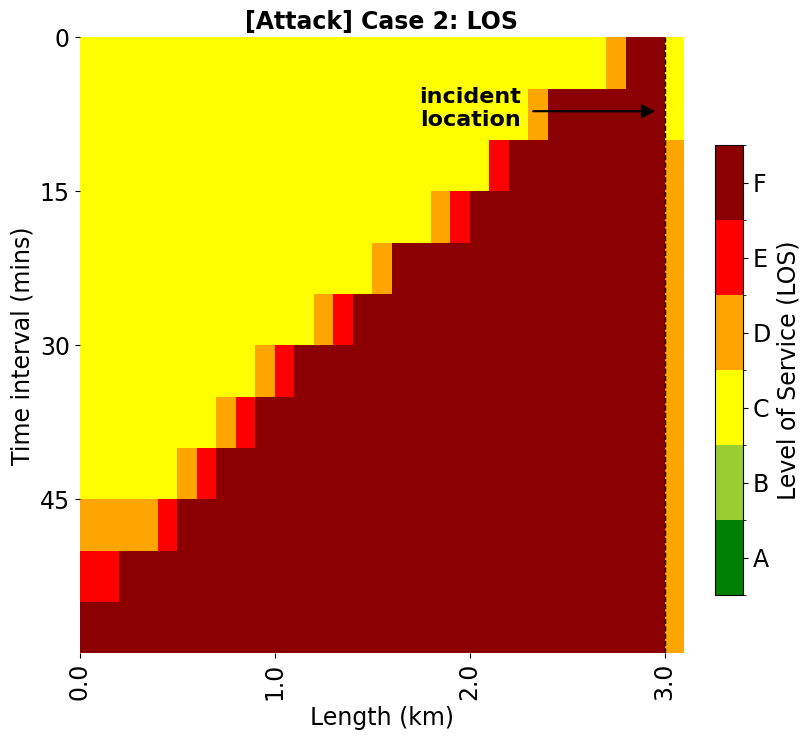

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------------------
# 1) Read data
# ------------------------------------------------------------------------
file_path = "data/combined_datav4.csv"
df = pd.read_csv(file_path)

df["time_bin"] = df["time_bin"].astype(int)
df["distance"] = df["distance"].astype(int)

# ------------------------------------------------------------------------
# 2) Attack only (keep Base in memory if needed later, but don't plot)
# ------------------------------------------------------------------------
df_attack = df[["time_bin", "distance", "LOS_attack"]].copy()
df_attack.rename(columns={"LOS_attack": "LOS"}, inplace=True)

# ------------------------------------------------------------------------
# 3) Filter by distance/time range (Case 2 window)
# ------------------------------------------------------------------------
distance_start = 0
distance_end   = 3000
time_start     = 54900
time_end       = 58200

df_attack = df_attack[
    (df_attack["distance"] >= distance_start) &
    (df_attack["distance"] <= distance_end) &
    (df_attack["time_bin"] >= time_start) &
    (df_attack["time_bin"] <= time_end)
]

# ------------------------------------------------------------------------
# 4) Pivot into matrix
# ------------------------------------------------------------------------
pivot_attack = df_attack.pivot(index="time_bin", columns="distance", values="LOS")

# ------------------------------------------------------------------------
# 5) Map LOS A–F → 1–6
# ------------------------------------------------------------------------
LOS_map = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6}
attack_numeric = pivot_attack.applymap(lambda x: LOS_map[x] if pd.notnull(x) else np.nan)

# ------------------------------------------------------------------------
# 6) Discrete colormap for LOS
# ------------------------------------------------------------------------
los_colors = ["green", "yellowgreen", "yellow", "orange", "red", "darkred"]
cmap = ListedColormap(los_colors)
bounds = [0.5,1.5,2.5,3.5,4.5,5.5,6.5]
norm = BoundaryNorm(bounds, cmap.N)

# ------------------------------------------------------------------------
# 7) Plot ATTACK heatmap only (polished layout)
# ------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 7.5))  # single panel

# --- Ticks: x in km, y every 15 min (relative to time_start for labels) ---
col_positions = np.arange(0, len(pivot_attack.columns), 10)
x_labels_km = [f"{pivot_attack.columns[i]/1000:.1f}" for i in col_positions]

time_values_rel = pivot_attack.index.values - time_start
y_tick_positions = [i for i, t in enumerate(time_values_rel) if (t % 900) == 0]   # 900s = 15 min
y_tick_labels    = [f"{int(time_values_rel[i] / 60)}" for i in y_tick_positions]  # minutes

# --- Heatmap (no seams) ---
sns.heatmap(
    attack_numeric, ax=ax, cmap=cmap, norm=norm,
    cbar=False, square=False, yticklabels=False,
    linewidths=0, linecolor=None
)

ax.set_title("[Attack] Case 2: LOS", fontsize=17, fontweight="bold")
ax.set_xlabel("Length (km)", fontsize=17)
ax.set_ylabel("Time interval (mins)", fontsize=17)
ax.set_xticks(col_positions)
ax.set_xticklabels(x_labels_km, rotation=90, fontsize=17)
ax.set_yticks(y_tick_positions)
ax.set_yticklabels(y_tick_labels, fontsize=17)

# --- Incident marker at 3000 m (if present) ---
if 3000 in pivot_attack.columns:
    col_idx = pivot_attack.columns.get_loc(3000)
    ax.axvline(x=col_idx, color="k", linestyle="--", lw=1)

# --- Annotation + arrow (incident location) ---
ax.text(
    0.73, 0.85, "incident\nlocation",
    transform=ax.transAxes, ha="right", va="bottom",
    color="black", fontsize=16, fontweight="bold"
)
ax.arrow(
    0.75, 0.88, 0.20, 0.00,
    transform=ax.transAxes, color="black",
    linewidth=1, head_width=0.02, head_length=0.02,
    length_includes_head=True, zorder=10
)

# --- Colourbar tucked to the right ---
cbar_ax = fig.add_axes([0.90, 0.20, 0.035, 0.60])  # [left, bottom, width, height]
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax, orientation='vertical')
cbar.set_ticks([1,2,3,4,5,6])
cbar.set_ticklabels(["A", "B", "C", "D", "E", "F"], fontsize=17)
cbar.set_label("Level of Service (LOS)", fontsize=17)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("LOSHigh-20-attack.pdf", bbox_inches="tight")   # vector PDF output
# plt.savefig("LOSHigh-20-attack.png", dpi=300, bbox_inches="tight")  # optional PNG
plt.show()


In [1]:
import pandas as pd

# Load the data
file_path = "data/combined_datav4.csv"
df = pd.read_csv(file_path)

# Convert time and distance to integers for comparison
df["time_bin"] = df["time_bin"].astype(int)
df["distance"] = df["distance"].astype(int)

# Define bounds
distance_start = 0
distance_end   = 3000
time_start     = 58200
time_end       = 58200

# Filter within bounds
filtered = df[
    (df["distance"] >= distance_start) &
    (df["distance"] <= distance_end) &
    (df["time_bin"] >= time_start) &
    (df["time_bin"] <= time_end)
]

# Convert density columns to numeric
filtered["density_base"] = pd.to_numeric(filtered["density_base"], errors='coerce')
filtered["density_attack"] = pd.to_numeric(filtered["density_attack"], errors='coerce')

# Compute means
mean_base_density = filtered["density_base"].mean()
mean_attack_density = filtered["density_attack"].mean()

# LOS classification function
def classify_LOS(density):
    if density <= 11:
        return "A"
    elif 11 < density <= 18:
        return "B"
    elif 18 < density <= 26:
        return "C"
    elif 26 < density <= 35:
        return "D"
    elif 35 < density <= 45:
        return "E"
    else:
        return "F"

# Classify based on mean densities
los_base = classify_LOS(mean_base_density)
los_attack = classify_LOS(mean_attack_density)

# Output results
print(f"Mean Base Density:   {mean_base_density:.2f} → LOS {los_base}")
print(f"Mean Attack Density: {mean_attack_density:.2f} → LOS {los_attack}")


Mean Base Density:   24.99 → LOS C
Mean Attack Density: 121.83 → LOS F


C:\Users\nalin\AppData\Local\Temp\ipykernel_36944\3015412491.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["density_base"] = pd.to_numeric(filtered["density_base"], errors='coerce')
C:\Users\nalin\AppData\Local\Temp\ipykernel_36944\3015412491.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["density_attack"] = pd.to_numeric(filtered["density_attack"], errors='coerce')


In [1]:
import pandas as pd

# ──────────────────────────────────────────────────────────────
# 1  Load data
# ──────────────────────────────────────────────────────────────
file_path = "data/combined_datav4.csv"
df = pd.read_csv(file_path)

# Ensure numeric types
df["time_bin"] = pd.to_numeric(df["time_bin"], errors='coerce').astype(int)
df["distance"] = pd.to_numeric(df["distance"], errors='coerce').astype(int)
df["density_base"]   = pd.to_numeric(df["density_base"],   errors='coerce')
df["density_attack"] = pd.to_numeric(df["density_attack"], errors='coerce')

# ──────────────────────────────────────────────────────────────
# 2  ROI filter
# ──────────────────────────────────────────────────────────────
distance_start, distance_end = 0, 3000
time_start,     time_end     = 54900, 58200

roi = df[
    (df["distance"].between(distance_start, distance_end)) &
    (df["time_bin"].between(time_start, time_end))
]

# ──────────────────────────────────────────────────────────────
# 3  Aggregate: mean density per interval
# ──────────────────────────────────────────────────────────────
mean_by_interval = (
    roi.groupby("time_bin")[["density_base", "density_attack"]]
       .mean()
       .reset_index()
       .rename(columns={"density_base":   "mean_density_base",
                        "density_attack": "mean_density_attack"})
)

# ──────────────────────────────────────────────────────────────
# 4  LOS classification helpers
# ──────────────────────────────────────────────────────────────
def classify_los(d):
    if d <= 11:          return "A"
    elif d <= 18:        return "B"
    elif d <= 26:        return "C"
    elif d <= 35:        return "D"
    elif d <= 45:        return "E"
    else:                return "F"

mean_by_interval["LOS_base"]   = mean_by_interval["mean_density_base"].apply(classify_los)
mean_by_interval["LOS_attack"] = mean_by_interval["mean_density_attack"].apply(classify_los)

# ──────────────────────────────────────────────────────────────
# 5  Save to CSV
# ──────────────────────────────────────────────────────────────
out_file = "los_by_interval.csv"
mean_by_interval.to_csv(out_file, index=False)
print(f"Saved {out_file} with {len(mean_by_interval)} intervals")

# Optional: quick preview
print(mean_by_interval.head())


Saved los_by_interval.csv with 12 intervals
   time_bin  mean_density_base  mean_density_attack LOS_base LOS_attack
0     54900          22.157497            24.954115        C          C
1     55200          20.902212            36.872575        C          E
2     55500          21.016423            46.140816        C          F
3     55800          23.359830            53.626324        C          F
4     56100          24.421994            64.650303        C          F
